# Training UAV-Human 5 Classes — Anti-Overfitting CNN-BiLSTM

Pipeline:

`X_sequences (90 × 51)` → normalisasi skeleton → subject-wise split → augmentasi skeleton hanya pada train → CNN-BiLSTM lebih kecil → evaluasi.

Kelas:

- `applaud`
- `wave_hands`
- `punch_with_fists`
- `squat`
- `step_on_the_spot_walk`

Strategi anti-overfitting:

- split berdasarkan `subject_ids.npy`;
- augmentasi skeleton hanya pada train;
- model lebih kecil;
- dropout lebih besar;
- L2 regularization;
- early stopping lebih cepat;
- learning-rate reduction;
- gradient clipping;
- class weight hanya jika distribusi train memang timpang.


In [1]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings("ignore")

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================================
# 2. KONFIGURASI
# ============================================================

SEED = 42

EXPERIMENT_NAME = (
    "UAV_HUMAN_5CLASS_H4_"
    "CNN_BILSTM_ANTI_OVERFITTING"
)

ACTIVITY_CLASSES = [
    "applaud",
    "wave_hands",
    "punch_with_fists",
    "squat",
    "step_on_the_spot_walk",
]

EXPECTED_SEQUENCE_LENGTH = 90
EXPECTED_FEATURES = 51
NUM_CLASSES = len(ACTIVITY_CLASSES)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

MAX_EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 5e-4

L2_REG = 3e-4

EARLY_STOPPING_PATIENCE = 12
REDUCE_LR_PATIENCE = 4

# Augmentasi hanya untuk train set
USE_AUGMENTATION = True
XY_NOISE_STD = 0.015
MAX_TEMPORAL_SHIFT = 4
FRAME_MASK_RATIO = 0.06
KEYPOINT_DROPOUT_RATE = 0.03

# Class weight hanya dipakai jika rasio kelas terbesar/kecil > batas ini
AUTO_CLASS_WEIGHT = True
CLASS_IMBALANCE_THRESHOLD = 1.50

OUTPUT_DIR = (
    Path("/kaggle/working/training_results")
    / EXPERIMENT_NAME
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed()

print("=" * 76)
print("TRAINING UAV-HUMAN 5 KELAS — ANTI OVERFITTING")
print("=" * 76)
print("Experiment :", EXPERIMENT_NAME)
print("Classes    :", ACTIVITY_CLASSES)
print("Output     :", OUTPUT_DIR)
print("=" * 76)

TRAINING UAV-HUMAN 5 KELAS — ANTI OVERFITTING
Experiment : UAV_HUMAN_5CLASS_H4_CNN_BILSTM_ANTI_OVERFITTING
Classes    : ['applaud', 'wave_hands', 'punch_with_fists', 'squat', 'step_on_the_spot_walk']
Output     : /kaggle/working/training_results/UAV_HUMAN_5CLASS_H4_CNN_BILSTM_ANTI_OVERFITTING


In [3]:
# ============================================================
# 3. KONFIGURASI DATASET UAV-HUMAN 5 KELAS
# ============================================================

DATA_DIR = Path(
    "/kaggle/input/datasets/wafabila/"
    "output-uav-human-5-classes/"
    "preprocessed_final/uav_human_5_classes/"
    "h4_yolo_detection_yolo26_pose_seq90"
)

print("=" * 76)
print("DATASET UAV-HUMAN 5 KELAS")
print("=" * 76)
print("DATA_DIR :", DATA_DIR)

if not DATA_DIR.exists():
    print()
    print("Path default tidak ditemukan.")
    print("Mencari dataset preprocessing secara otomatis...")

    candidates = []

    for x_path in Path("/kaggle/input").rglob("X_sequences.npy"):
        try:
            shape = np.load(
                x_path,
                mmap_mode="r",
                allow_pickle=False,
            ).shape
        except Exception:
            continue

        if (
            len(shape) == 3
            and shape[1] == EXPECTED_SEQUENCE_LENGTH
            and shape[2] == EXPECTED_FEATURES
        ):
            folder = x_path.parent

            required = [
                "y_labels.npy",
                "subject_ids.npy",
                "source_video_ids.npy",
            ]

            if all(
                (folder / name).exists()
                for name in required
            ):
                text = str(folder).lower()
                score = 0

                if "uav" in text:
                    score += 10
                if "human" in text:
                    score += 10
                if "5_class" in text or "5-class" in text:
                    score += 20
                if "h4" in text:
                    score += 10
                if "seq90" in text:
                    score += 5
                if "debug" in text:
                    score -= 20

                candidates.append(
                    {
                        "folder": folder,
                        "shape": shape,
                        "score": score,
                    }
                )

    if not candidates:
        raise FileNotFoundError(
            "Dataset preprocessing 5 kelas tidak ditemukan "
            "di /kaggle/input."
        )

    candidates = sorted(
        candidates,
        key=lambda item: (
            item["score"],
            item["shape"][0],
        ),
        reverse=True,
    )

    print()
    print("Kandidat dataset:")

    for index, item in enumerate(candidates[:10]):
        print(
            f"[{index}] shape={item['shape']} "
            f"score={item['score']}\n"
            f"    {item['folder']}"
        )

    DATA_DIR = candidates[0]["folder"]

print()
print("DATASET TERPILIH :", DATA_DIR)

required_files = [
    "X_sequences.npy",
    "y_labels.npy",
    "video_ids.npy",
    "source_video_ids.npy",
    "subject_ids.npy",
]

for file_name in required_files:
    file_path = DATA_DIR / file_name

    print(
        f"{file_name:25s}: "
        f"{'ADA' if file_path.exists() else 'TIDAK ADA'}"
    )

    if not file_path.exists():
        raise FileNotFoundError(file_path)

print("Dataset siap.")

DATASET UAV-HUMAN 5 KELAS
DATA_DIR : /kaggle/input/datasets/wafabila/output-uav-human-5-classes/preprocessed_final/uav_human_5_classes/h4_yolo_detection_yolo26_pose_seq90

Path default tidak ditemukan.
Mencari dataset preprocessing secara otomatis...

Kandidat dataset:
[0] shape=(3634, 90, 51) score=55
    /kaggle/input/datasets/wafabila/output-uav-human-5-clases/preprocessed_final/uav_human_5_classes/h4_yolo_detection_yolo26_pose_seq90

DATASET TERPILIH : /kaggle/input/datasets/wafabila/output-uav-human-5-clases/preprocessed_final/uav_human_5_classes/h4_yolo_detection_yolo26_pose_seq90
X_sequences.npy          : ADA
y_labels.npy             : ADA
video_ids.npy            : ADA
source_video_ids.npy     : ADA
subject_ids.npy          : ADA
Dataset siap.


In [4]:
# ============================================================
# 4. LOAD DAN VALIDASI DATASET
# ============================================================

X_raw = np.load(
    DATA_DIR / "X_sequences.npy",
    allow_pickle=False,
).astype(np.float32)

y = np.load(
    DATA_DIR / "y_labels.npy",
    allow_pickle=False,
).astype(np.int64)

subject_ids = np.load(
    DATA_DIR / "subject_ids.npy",
    allow_pickle=False,
).astype(str)

source_video_ids = np.load(
    DATA_DIR / "source_video_ids.npy",
    allow_pickle=False,
).astype(str)

sequence_ids = np.load(
    DATA_DIR / "video_ids.npy",
    allow_pickle=False,
).astype(str)

assert X_raw.ndim == 3
assert X_raw.shape[1:] == (
    EXPECTED_SEQUENCE_LENGTH,
    EXPECTED_FEATURES,
)

assert (
    len(X_raw)
    == len(y)
    == len(subject_ids)
    == len(source_video_ids)
    == len(sequence_ids)
)

assert np.isfinite(X_raw).all()

unique_labels = np.unique(y)

if set(unique_labels) != set(range(NUM_CLASSES)):
    raise ValueError(
        f"Label dataset {unique_labels.tolist()} "
        f"tidak sesuai dengan {NUM_CLASSES} kelas."
    )

unknown_subject_mask = (
    np.char.upper(subject_ids.astype(str))
    == "UNKNOWN"
)

if unknown_subject_mask.any():
    print(
        "Sequence dengan subject UNKNOWN dibuang:",
        int(unknown_subject_mask.sum()),
    )

    keep = ~unknown_subject_mask

    X_raw = X_raw[keep]
    y = y[keep]
    subject_ids = subject_ids[keep]
    source_video_ids = source_video_ids[keep]
    sequence_ids = sequence_ids[keep]

distribution = (
    pd.DataFrame(
        {
            "label": y,
            "class": [
                ACTIVITY_CLASSES[index]
                for index in y
            ],
        }
    )
    .groupby(
        ["label", "class"],
        as_index=False,
    )
    .size()
    .rename(
        columns={"size": "sequences"}
    )
)

print("X shape         :", X_raw.shape)
print("y shape         :", y.shape)
print("Unique subjects :", len(np.unique(subject_ids)))
print("Unique videos   :", len(np.unique(source_video_ids)))
print()
display(distribution)

X shape         : (3634, 90, 51)
y shape         : (3634,)
Unique subjects : 95
Unique videos   : 549



,label,class,sequences
0,0,applaud,818
1,1,wave_hands,800
2,2,punch_with_fists,809
3,3,squat,270
4,4,step_on_the_spot_walk,937


In [5]:
# ============================================================
# 5. NORMALISASI SKELETON COCO-17
# ============================================================

# Input per frame:
# [x0, y0, conf0, x1, y1, conf1, ..., x16, y16, conf16]
#
# Normalisasi:
# - pusat skeleton = midpoint hip kiri-kanan (11, 12)
# - fallback pusat = midpoint shoulder (5, 6)
# - skala = jarak shoulder-center ke hip-center
# - fallback skala = diagonal bounding skeleton
# - confidence dipertahankan
# - frame kosong tetap nol

LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_HIP = 11
RIGHT_HIP = 12

EPSILON = 1e-6


def normalize_coco17_sequences(X):
    X = np.asarray(X, dtype=np.float32)

    reshaped = X.reshape(
        -1,
        EXPECTED_SEQUENCE_LENGTH,
        17,
        3,
    )

    output = np.zeros_like(
        reshaped,
        dtype=np.float32,
    )

    for sequence_index in range(len(reshaped)):
        for frame_index in range(EXPECTED_SEQUENCE_LENGTH):
            frame = reshaped[
                sequence_index,
                frame_index,
            ]

            xy = frame[:, :2]
            confidence = frame[:, 2]

            # Frame invalid dari preprocessing disimpan seluruhnya nol.
            if (
                np.allclose(xy, 0.0)
                and np.allclose(confidence, 0.0)
            ):
                continue

            valid = confidence > 0.0

            if valid.sum() < 2:
                continue

            left_hip_valid = confidence[LEFT_HIP] > 0
            right_hip_valid = confidence[RIGHT_HIP] > 0
            left_shoulder_valid = confidence[LEFT_SHOULDER] > 0
            right_shoulder_valid = confidence[RIGHT_SHOULDER] > 0

            if left_hip_valid and right_hip_valid:
                center = (
                    xy[LEFT_HIP]
                    + xy[RIGHT_HIP]
                ) / 2.0
            elif left_shoulder_valid and right_shoulder_valid:
                center = (
                    xy[LEFT_SHOULDER]
                    + xy[RIGHT_SHOULDER]
                ) / 2.0
            else:
                center = np.mean(
                    xy[valid],
                    axis=0,
                )

            scale = 0.0

            if (
                left_hip_valid
                and right_hip_valid
                and left_shoulder_valid
                and right_shoulder_valid
            ):
                hip_center = (
                    xy[LEFT_HIP]
                    + xy[RIGHT_HIP]
                ) / 2.0

                shoulder_center = (
                    xy[LEFT_SHOULDER]
                    + xy[RIGHT_SHOULDER]
                ) / 2.0

                scale = float(
                    np.linalg.norm(
                        shoulder_center
                        - hip_center
                    )
                )

            if scale <= EPSILON:
                valid_xy = xy[valid]

                width = float(
                    np.ptp(valid_xy[:, 0])
                )

                height = float(
                    np.ptp(valid_xy[:, 1])
                )

                scale = float(
                    np.hypot(width, height)
                )

            if scale <= EPSILON:
                scale = 1.0

            normalized_xy = (
                xy - center
            ) / scale

            # Titik tanpa confidence jangan membawa koordinat acak.
            normalized_xy[~valid] = 0.0

            output[
                sequence_index,
                frame_index,
                :,
                :2,
            ] = normalized_xy

            output[
                sequence_index,
                frame_index,
                :,
                2,
            ] = confidence

    # Batasi outlier koordinat hasil pembagian skala torso sangat kecil.
    output[..., :2] = np.clip(
        output[..., :2],
        -5.0,
        5.0,
    )

    output = output.reshape(
        -1,
        EXPECTED_SEQUENCE_LENGTH,
        EXPECTED_FEATURES,
    )

    output = np.nan_to_num(
        output,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)

    return output


X = normalize_coco17_sequences(X_raw)

print("Shape normalized :", X.shape)
print("Finite           :", np.isfinite(X).all())
print("Min              :", float(X.min()))
print("Max              :", float(X.max()))

Shape normalized : (3634, 90, 51)
Finite           : True
Min              : -5.0
Max              : 5.0


In [6]:
# ============================================================
# 6. SUBJECT-WISE SPLIT 70/15/15
# ============================================================

def class_distribution(indices, split_name):
    values, counts = np.unique(
        y[indices],
        return_counts=True,
    )

    rows = []

    for label in range(NUM_CLASSES):
        count = int(
            counts[
                np.where(values == label)[0][0]
            ]
        ) if label in values else 0

        rows.append({
            "split": split_name,
            "label": label,
            "class": ACTIVITY_CLASSES[label],
            "sequences": count,
        })

    return rows


# Split 1: train 70%, temporary 30%.
splitter_train = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_RATIO,
    random_state=SEED,
)

train_idx, temporary_idx = next(
    splitter_train.split(
        X,
        y,
        groups=subject_ids,
    )
)

# Split 2: temporary dibagi sama rata menjadi validation dan test.
temporary_subjects = subject_ids[temporary_idx]

relative_val_ratio = (
    VAL_RATIO / (VAL_RATIO + TEST_RATIO)
)

splitter_val_test = GroupShuffleSplit(
    n_splits=1,
    train_size=relative_val_ratio,
    random_state=SEED + 1,
)

relative_val_idx, relative_test_idx = next(
    splitter_val_test.split(
        X[temporary_idx],
        y[temporary_idx],
        groups=temporary_subjects,
    )
)

val_idx = temporary_idx[relative_val_idx]
test_idx = temporary_idx[relative_test_idx]

train_subjects = set(subject_ids[train_idx])
val_subjects = set(subject_ids[val_idx])
test_subjects = set(subject_ids[test_idx])

assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)

for split_name, indices in [
    ("train", train_idx),
    ("validation", val_idx),
    ("test", test_idx),
]:
    split_labels = set(np.unique(y[indices]))

    if split_labels != set(range(NUM_CLASSES)):
        raise RuntimeError(
            f"Split {split_name} tidak memiliki semua kelas. "
            "Ubah SEED atau gunakan lebih banyak data."
        )

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

split_distribution = pd.DataFrame(
    class_distribution(train_idx, "train")
    + class_distribution(val_idx, "validation")
    + class_distribution(test_idx, "test")
)

display(split_distribution)

print("Train sequences :", len(train_idx))
print("Val sequences   :", len(val_idx))
print("Test sequences  :", len(test_idx))
print()
print("Train subjects  :", len(train_subjects))
print("Val subjects    :", len(val_subjects))
print("Test subjects   :", len(test_subjects))
print()
print("Leakage subject : 0")

,split,label,class,sequences
0,train,0,applaud,598
1,train,1,wave_hands,578
2,train,2,punch_with_fists,586
3,train,3,squat,208
4,train,4,step_on_the_spot_walk,680
5,validation,0,applaud,119
6,validation,1,wave_hands,125
7,validation,2,punch_with_fists,121
8,validation,3,squat,37
9,validation,4,step_on_the_spot_walk,141


Train sequences : 2650
Val sequences   : 543
Test sequences  : 441

Train subjects  : 66
Val subjects    : 14
Test subjects   : 15

Leakage subject : 0


In [7]:
# ============================================================
# 7. SIMPAN INFORMASI SPLIT
# ============================================================

split_manifest = pd.DataFrame({
    "sequence_id": sequence_ids,
    "source_video_id": source_video_ids,
    "subject_id": subject_ids,
    "label": y,
    "class": [
        ACTIVITY_CLASSES[label]
        for label in y
    ],
    "split": "",
})

split_manifest.loc[
    train_idx,
    "split",
] = "train"

split_manifest.loc[
    val_idx,
    "split",
] = "validation"

split_manifest.loc[
    test_idx,
    "split",
] = "test"

split_manifest.to_csv(
    OUTPUT_DIR / "split_manifest.csv",
    index=False,
)

split_distribution.to_csv(
    OUTPUT_DIR / "split_distribution.csv",
    index=False,
)

np.save(
    OUTPUT_DIR / "train_indices.npy",
    train_idx,
)

np.save(
    OUTPUT_DIR / "val_indices.npy",
    val_idx,
)

np.save(
    OUTPUT_DIR / "test_indices.npy",
    test_idx,
)

print("Split artifacts tersimpan.")

Split artifacts tersimpan.


In [8]:
# ============================================================
# 8. CLASS WEIGHT OTOMATIS
# ============================================================

train_class_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES,
)

largest_class = int(
    train_class_counts.max()
)

smallest_class = int(
    train_class_counts.min()
)

imbalance_ratio = (
    largest_class / max(smallest_class, 1)
)

if (
    AUTO_CLASS_WEIGHT
    and imbalance_ratio
    > CLASS_IMBALANCE_THRESHOLD
):
    classes_present = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes_present,
        y=y_train,
    )

    class_weight = {
        int(label): float(weight)
        for label, weight in zip(
            classes_present,
            weights,
        )
    }
else:
    class_weight = None

print("Train class counts :", train_class_counts.tolist())
print("Imbalance ratio    :", round(imbalance_ratio, 3))
print("Class weight       :", class_weight)

Train class counts : [598, 578, 586, 208, 680]
Imbalance ratio    : 3.269
Class weight       : {0: 0.8862876254180602, 1: 0.916955017301038, 2: 0.9044368600682594, 3: 2.548076923076923, 4: 0.7794117647058824}


In [9]:
# ============================================================
# 9. TF.DATA + AUGMENTASI SKELETON
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


def augment_skeleton(sequence, label):
    skeleton = tf.reshape(
        sequence,
        (
            EXPECTED_SEQUENCE_LENGTH,
            17,
            3,
        ),
    )

    xy = skeleton[..., :2]
    confidence = skeleton[..., 2:3]

    valid_keypoints = confidence > 0.0

    # Jitter kecil hanya pada koordinat keypoint valid.
    noise = tf.random.normal(
        tf.shape(xy),
        mean=0.0,
        stddev=XY_NOISE_STD,
        dtype=tf.float32,
    )

    xy = tf.where(
        valid_keypoints,
        xy + noise,
        xy,
    )

    # Random temporal shift kecil.
    shift = tf.random.uniform(
        shape=[],
        minval=-MAX_TEMPORAL_SHIFT,
        maxval=MAX_TEMPORAL_SHIFT + 1,
        dtype=tf.int32,
    )

    xy = tf.roll(
        xy,
        shift=shift,
        axis=0,
    )

    confidence = tf.roll(
        confidence,
        shift=shift,
        axis=0,
    )

    # Mask sebagian frame secara acak.
    frame_mask = (
        tf.random.uniform(
            (
                EXPECTED_SEQUENCE_LENGTH,
                1,
                1,
            )
        )
        < FRAME_MASK_RATIO
    )

    xy = tf.where(
        frame_mask,
        tf.zeros_like(xy),
        xy,
    )

    confidence = tf.where(
        frame_mask,
        tf.zeros_like(confidence),
        confidence,
    )

    # Dropout keypoint kecil.
    keypoint_mask = (
        tf.random.uniform(
            (
                EXPECTED_SEQUENCE_LENGTH,
                17,
                1,
            )
        )
        < KEYPOINT_DROPOUT_RATE
    )

    xy = tf.where(
        keypoint_mask,
        tf.zeros_like(xy),
        xy,
    )

    confidence = tf.where(
        keypoint_mask,
        tf.zeros_like(confidence),
        confidence,
    )

    augmented = tf.concat(
        [xy, confidence],
        axis=-1,
    )

    augmented = tf.reshape(
        augmented,
        (
            EXPECTED_SEQUENCE_LENGTH,
            EXPECTED_FEATURES,
        ),
    )

    return augmented, label


def make_dataset(
    features,
    labels,
    training=False,
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (features, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(features),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

        if USE_AUGMENTATION:
            dataset = dataset.map(
                augment_skeleton,
                num_parallel_calls=AUTOTUNE,
            )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_dataset = make_dataset(
    X_train,
    y_train,
    training=True,
)

val_dataset = make_dataset(
    X_val,
    y_val,
    training=False,
)

test_dataset = make_dataset(
    X_test,
    y_test,
    training=False,
)

print("Augmentasi train :", USE_AUGMENTATION)
print(train_dataset)

I0000 00:00:1784135039.856392      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784135039.859296      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Augmentasi train : True
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 90, 51), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [10]:
# ============================================================
# 10. MODEL CNN-BILSTM LEBIH KECIL
# ============================================================

def build_cnn_bilstm(
    input_shape,
    num_classes,
):
    inputs = keras.Input(
        shape=input_shape,
        name="skeleton_sequence",
    )

    x = layers.Masking(
        mask_value=0.0,
        name="mask_invalid_frames",
    )(inputs)

    x = layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(
            L2_REG
        ),
        name="conv1d_32",
    )(x)

    x = layers.BatchNormalization(
        name="bn_1",
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_1",
    )(x)

    x = layers.Dropout(
        0.25,
        name="dropout_conv_1",
    )(x)

    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(
            L2_REG
        ),
        name="conv1d_64",
    )(x)

    x = layers.BatchNormalization(
        name="bn_2",
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_2",
    )(x)

    x = layers.MaxPooling1D(
        pool_size=2,
        name="max_pool",
    )(x)

    x = layers.Dropout(
        0.35,
        name="dropout_conv_2",
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.25,
            recurrent_dropout=0.0,
            kernel_regularizer=regularizers.l2(
                L2_REG
            ),
        ),
        name="bilstm_64",
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            32,
            return_sequences=False,
            dropout=0.25,
            recurrent_dropout=0.0,
            kernel_regularizer=regularizers.l2(
                L2_REG
            ),
        ),
        name="bilstm_32",
    )(x)

    x = layers.Dense(
        64,
        use_bias=False,
        kernel_regularizer=regularizers.l2(
            L2_REG
        ),
        name="dense_64",
    )(x)

    x = layers.BatchNormalization(
        name="bn_dense",
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_dense",
    )(x)

    x = layers.Dropout(
        0.50,
        name="dropout_dense",
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="activity_output",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="CNN_BiLSTM_AntiOverfitting",
    )

    return model


model = build_cnn_bilstm(
    input_shape=(
        EXPECTED_SEQUENCE_LENGTH,
        EXPECTED_FEATURES,
    ),
    num_classes=NUM_CLASSES,
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0,
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ],
)

model.summary()

print()
print("Total parameter:", model.count_params())

Model: "CNN_BiLSTM_AntiOverfitting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skeleton_sequence (InputLayer)  │ (None, 90, 51)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mask_invalid_frames (Masking)   │ (None, 90, 51)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 90, 32)         │         8,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 90, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_1 (Dropout)        │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_64 (Conv1D)              │ (None, 90, 64)         │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 90, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool (MaxPooling1D)         │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_2 (Dropout)        │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_64 (Bidirectional)       │ (None, 45, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_32 (Bidirectional)       │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_output (Dense)         │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,629 (494.64 KB)

 Trainable params: 126,309 (493.39 KB)

 Non-trainable params: 320 (1.25 KB)


Total parameter: 126629


In [11]:
# ============================================================
# 11. CALLBACKS
# ============================================================

BEST_MODEL_PATH = (
    OUTPUT_DIR / "best_model.keras"
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(
        str(
            OUTPUT_DIR / "training_log.csv"
        )
    ),
]

In [12]:
# ============================================================
# 12. TRAINING
# ============================================================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
)

print("Training selesai.")

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2173 - loss: 2.2494
Epoch 1: val_loss improved from None to 1.63707, saving model to /kaggle/working/training_results/UAV_HUMAN_5CLASS_H4_CNN_BILSTM_ANTI_OVERFITTING/best_model.keras

Epoch 1: finished saving model to /kaggle/working/training_results/UAV_HUMAN_5CLASS_H4_CNN_BILSTM_ANTI_OVERFITTING/best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.2691 - loss: 2.0275 - val_accuracy: 0.3886 - val_loss: 1.6371 - learning_rate: 5.0000e-04
Epoch 2/100
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4419 - loss: 1.4822
Epoch 2: val_loss did not improve from 1.63707
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5034 - loss: 1.3797 - val_accuracy: 0.3517 - val_loss: 1.6453 - learning_rate: 5.0000e-04
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6065 - loss: 1.1927
Epoch 3: val_loss improved from 1.63707 to 1.61819, saving model to /kaggle/working/training_results/UAV_HUMAN

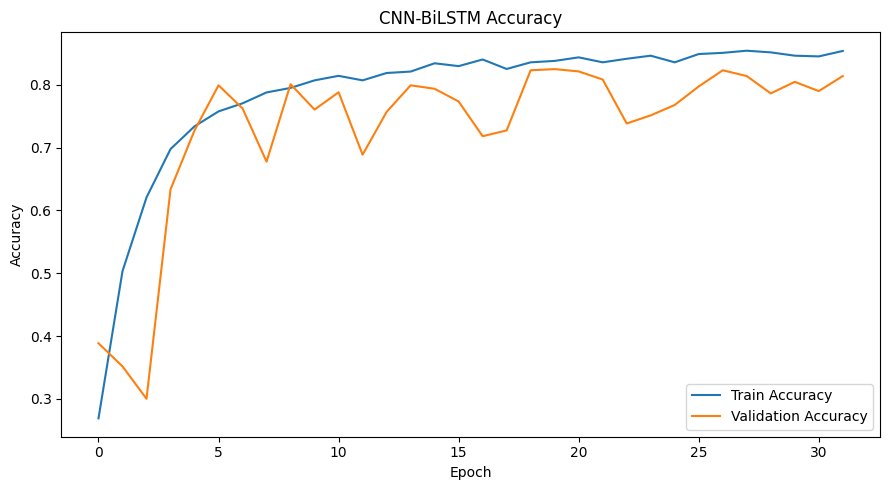

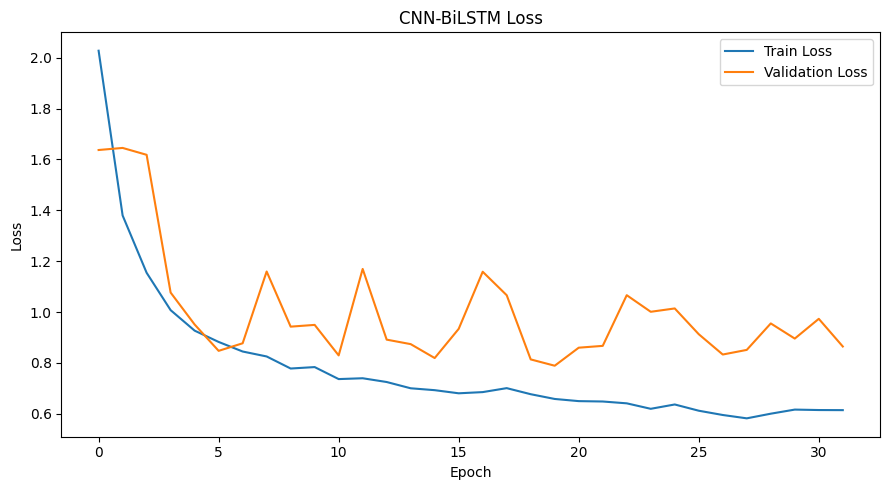

OVERFITTING CHECK
Best epoch        : 20
Train accuracy    : 83.81%
Validation acc    : 82.50%
Train-val gap     : 1.31%
Gap status        : RENDAH


In [13]:
# ============================================================
# 13. TRAINING CURVES DAN OVERFITTING GAP
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(
    history.history["accuracy"],
    label="Train Accuracy",
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-BiLSTM Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "accuracy_curve.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    history.history["loss"],
    label="Train Loss",
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-BiLSTM Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "loss_curve.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

best_epoch_by_loss = int(
    np.argmin(
        history.history["val_loss"]
    )
)

train_accuracy_best = float(
    history.history["accuracy"][
        best_epoch_by_loss
    ]
)

val_accuracy_best = float(
    history.history["val_accuracy"][
        best_epoch_by_loss
    ]
)

overfitting_gap = (
    train_accuracy_best
    - val_accuracy_best
)

print("=" * 76)
print("OVERFITTING CHECK")
print("=" * 76)
print("Best epoch        :", best_epoch_by_loss + 1)
print(
    "Train accuracy    :",
    f"{train_accuracy_best * 100:.2f}%",
)
print(
    "Validation acc    :",
    f"{val_accuracy_best * 100:.2f}%",
)
print(
    "Train-val gap     :",
    f"{overfitting_gap * 100:.2f}%",
)

if overfitting_gap <= 0.05:
    gap_status = "RENDAH"
elif overfitting_gap <= 0.10:
    gap_status = "SEDANG"
else:
    gap_status = "TINGGI"

print("Gap status        :", gap_status)
print("=" * 76)

In [14]:
# ============================================================
# 14. LOAD BEST MODEL DAN EVALUASI
# ============================================================

best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    compile=False,
)

best_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0,
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ],
)

test_loss, test_accuracy_keras = (
    best_model.evaluate(
        test_dataset,
        verbose=1,
    )
)

probabilities = best_model.predict(
    test_dataset,
    verbose=1,
)

predictions = np.argmax(
    probabilities,
    axis=1,
)

accuracy = accuracy_score(
    y_test,
    predictions,
)

precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_test,
        predictions,
        average="macro",
        zero_division=0,
    )
)

precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_test,
        predictions,
        average="weighted",
        zero_division=0,
    )
)

print("=" * 76)
print("HASIL TEST UAV-HUMAN H4")
print("=" * 76)
print(f"Loss               : {test_loss:.4f}")
print(f"Accuracy           : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Macro Precision    : {precision_macro:.4f}")
print(f"Macro Recall       : {recall_macro:.4f}")
print(f"Macro F1           : {f1_macro:.4f}")
print(f"Weighted Precision : {precision_weighted:.4f}")
print(f"Weighted Recall    : {recall_weighted:.4f}")
print(f"Weighted F1        : {f1_weighted:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8209 - loss: 0.7418
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
HASIL TEST UAV-HUMAN H4
Loss               : 0.7418
Accuracy           : 0.8209 (82.09%)
Macro Precision    : 0.8358
Macro Recall       : 0.8448
Macro F1           : 0.8132
Weighted Precision : 0.8420
Weighted Recall    : 0.8209
Weighted F1        : 0.8019


In [15]:
# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_test,
    predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=ACTIVITY_CLASSES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(report_df)

report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv"
)

,precision,recall,f1-score,support
applaud,0.708955,0.940594,0.808511,101.000000
wave_hands,0.862745,0.907216,0.884422,97.000000
punch_with_fists,0.931818,0.401961,0.561644,102.000000
squat,0.806452,1.000000,0.892857,25.000000
step_on_the_spot_walk,0.869231,0.974138,0.918699,116.000000
accuracy,0.820862,0.820862,0.820862,0.820862
macro avg,0.835840,0.844782,0.813227,441.000000
weighted avg,0.842014,0.820862,0.801875,441.000000


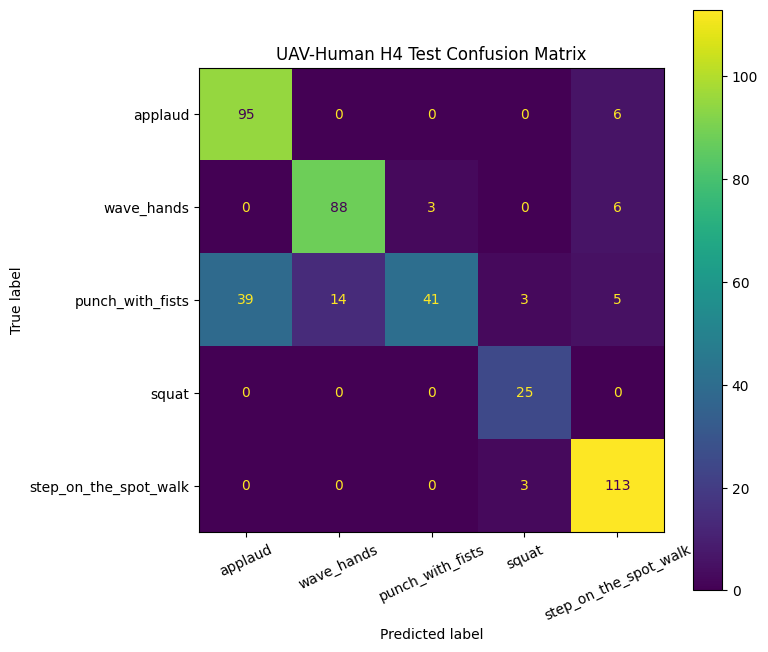

In [16]:
# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

matrix = confusion_matrix(
    y_test,
    predictions,
    labels=list(range(NUM_CLASSES)),
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=ACTIVITY_CLASSES,
)

display_matrix.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=25,
)

plt.title(
    "UAV-Human H4 Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [17]:
# ============================================================
# 17. SIMPAN PREDIKSI TEST
# ============================================================

test_predictions_df = pd.DataFrame({
    "sequence_id": sequence_ids[test_idx],
    "source_video_id": source_video_ids[test_idx],
    "subject_id": subject_ids[test_idx],
    "true_label": y_test,
    "true_class": [
        ACTIVITY_CLASSES[label]
        for label in y_test
    ],
    "predicted_label": predictions,
    "predicted_class": [
        ACTIVITY_CLASSES[label]
        for label in predictions
    ],
    "confidence": np.max(
        probabilities,
        axis=1,
    ),
    "correct": (
        y_test == predictions
    ),
})

for class_index, class_name in enumerate(
    ACTIVITY_CLASSES
):
    test_predictions_df[
        f"prob_{class_name}"
    ] = probabilities[:, class_index]

test_predictions_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)

display(
    test_predictions_df.head(20)
)

,sequence_id,source_video_id,subject_id,true_label,true_class,predicted_label,predicted_class,confidence,correct,prob_applaud,prob_wave_hands,prob_punch_with_fists,prob_squat,prob_step_on_the_spot_walk
0,P018S01G10B00H00UC012000LC022000A008R0_0911143...,P018S01G10B00H00UC012000LC022000A008R0_09111438,P018,0,applaud,0,applaud,0.962798,True,0.962798,0.000115,0.035856,0.000571,0.000660
1,P018S01G10B00H00UC012000LC022000A008R0_0911143...,P018S01G10B00H00UC012000LC022000A008R0_09111438,P018,0,applaud,0,applaud,0.953566,True,0.953566,0.000146,0.044883,0.000843,0.000562
2,P018S01G10B00H00UC012000LC022000A008R0_0911143...,P018S01G10B00H00UC012000LC022000A008R0_09111438,P018,0,applaud,0,applaud,0.954287,True,0.954287,0.000149,0.044101,0.000708,0.000755
3,P018S01G10B00H00UC012000LC022000A008R0_0911143...,P018S01G10B00H00UC012000LC022000A008R0_09111438,P018,0,applaud,0,applaud,0.916433,True,0.916433,0.000294,0.081132,0.000926,0.001215
4,P018S01G10B00H00UC012000LC022000A008R0_0911143...,P018S01G10B00H00UC012000LC022000A008R0_09111438,P018,0,applaud,0,applaud,0.812138,True,0.812138,0.000653,0.184472,0.001060,0.001676
5,P022S01G10B00H10UC072000LC021000A008R0_0907105...,P022S01G10B00H10UC072000LC021000A008R0_09071055,P022,0,applaud,0,applaud,0.690908,True,0.690908,0.007304,0.087611,0.093323,0.120854
6,P022S01G10B00H10UC072000LC021000A008R0_0907105...,P022S01G10B00H10UC072000LC021000A008R0_09071055,P022,0,applaud,0,applaud,0.984189,True,0.984189,0.000070,0.012760,0.001568,0.001413
7,P022S01G10B00H10UC072000LC021000A008R0_0907105...,P022S01G10B00H10UC072000LC021000A008R0_09071055,P022,0,applaud,0,applaud,0.990274,True,0.990274,0.000032,0.008237,0.000902,0.000555
8,P022S01G10B00H10UC072000LC021000A008R0_0907105...,P022S01G10B00H10UC072000LC021000A008R0_09071055,P022,0,applaud,0,applaud,0.989985,True,0.989985,0.000031,0.008514,0.000945,0.000524
9,P022S01G10B00H10UC072000LC021000A008R0_0907105...,P022S01G10B00H10UC072000LC021000A008R0_09071055,P022,0,applaud,0,applaud,0.988961,True,0.988961,0.000034,0.009403,0.001049,0.000552


In [18]:
# ============================================================
# 18. SIMPAN MODEL DAN RINGKASAN
# ============================================================

FINAL_MODEL_PATH = (
    OUTPUT_DIR / "final_model.keras"
)

best_model.save(
    FINAL_MODEL_PATH
)

with open(
    OUTPUT_DIR / "class_mapping.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            index: class_name
            for index, class_name
            in enumerate(
                ACTIVITY_CLASSES
            )
        },
        file,
        indent=2,
        ensure_ascii=False,
    )

best_epoch = int(
    np.argmin(
        history.history["val_loss"]
    )
    + 1
)

summary = {
    "experiment_name": EXPERIMENT_NAME,
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "classes": ACTIVITY_CLASSES,
    "input_shape": [
        EXPECTED_SEQUENCE_LENGTH,
        EXPECTED_FEATURES,
    ],
    "normalization": (
        "COCO-17 hip-centered and torso-scale; "
        "confidence retained"
    ),
    "anti_overfitting": {
        "subject_wise_split": True,
        "augmentation": USE_AUGMENTATION,
        "xy_noise_std": XY_NOISE_STD,
        "max_temporal_shift": MAX_TEMPORAL_SHIFT,
        "frame_mask_ratio": FRAME_MASK_RATIO,
        "keypoint_dropout_rate": KEYPOINT_DROPOUT_RATE,
        "l2_regularization": L2_REG,
        "dense_dropout": 0.50,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "model_parameters": int(
            model.count_params()
        ),
    },
    "split": {
        "method": (
            "GroupShuffleSplit "
            "by subject_ids"
        ),
        "train_ratio": TRAIN_RATIO,
        "validation_ratio": VAL_RATIO,
        "test_ratio": TEST_RATIO,
        "train_sequences": int(
            len(train_idx)
        ),
        "validation_sequences": int(
            len(val_idx)
        ),
        "test_sequences": int(
            len(test_idx)
        ),
        "train_subjects": int(
            len(train_subjects)
        ),
        "validation_subjects": int(
            len(val_subjects)
        ),
        "test_subjects": int(
            len(test_subjects)
        ),
        "subject_leakage": 0,
    },
    "training": {
        "max_epochs": MAX_EPOCHS,
        "best_epoch_by_val_loss": best_epoch,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "class_weight": class_weight,
    },
    "overfitting_check": {
        "train_accuracy_best_epoch": (
            train_accuracy_best
        ),
        "validation_accuracy_best_epoch": (
            val_accuracy_best
        ),
        "train_validation_gap": (
            overfitting_gap
        ),
        "gap_status": gap_status,
    },
    "test_metrics": {
        "loss": float(test_loss),
        "accuracy": float(accuracy),
        "macro_precision": float(
            precision_macro
        ),
        "macro_recall": float(
            recall_macro
        ),
        "macro_f1": float(
            f1_macro
        ),
        "weighted_precision": float(
            precision_weighted
        ),
        "weighted_recall": float(
            recall_weighted
        ),
        "weighted_f1": float(
            f1_weighted
        ),
    },
    "model_path": str(
        FINAL_MODEL_PATH
    ),
    "best_model_path": str(
        BEST_MODEL_PATH
    ),
}

with open(
    OUTPUT_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("=" * 76)
print("TRAINING UAV-HUMAN 5 KELAS SELESAI")
print("=" * 76)
print("Best epoch      :", best_epoch)
print(
    "Test accuracy   :",
    f"{accuracy * 100:.2f}%",
)
print(
    "Macro F1        :",
    f"{f1_macro * 100:.2f}%",
)
print(
    "Train-val gap   :",
    f"{overfitting_gap * 100:.2f}%",
)
print("Gap status      :", gap_status)
print("Model           :", FINAL_MODEL_PATH)
print("Output          :", OUTPUT_DIR)
print("=" * 76)

TRAINING UAV-HUMAN 5 KELAS SELESAI
Best epoch      : 20
Test accuracy   : 82.09%
Macro F1        : 81.32%
Train-val gap   : 1.31%
Gap status      : RENDAH
Model           : /kaggle/working/training_results/UAV_HUMAN_5CLASS_H4_CNN_BILSTM_ANTI_OVERFITTING/final_model.keras
Output          : /kaggle/working/training_results/UAV_HUMAN_5CLASS_H4_CNN_BILSTM_ANTI_OVERFITTING
